In [ ]:
import copy
import numpy as np

import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F

import torchvision
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset,Subset
from torchvision import transforms
from torchvision.transforms import Compose, Normalize, Pad
from torchvision import models

import cv2
from PIL import Image
import pandas as pd

import matplotlib.pyplot as plt
from torchvision.ops import nms

from PIL import Image, ImageDraw, ImageFont

import os
import time

In [ ]:
label_semantic_dataset_path = "/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/label_images_semantic"
original_images_path = "/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/original_images"

In [ ]:
image_names = os.listdir(original_images_path)
semantic_names = os.listdir(label_semantic_dataset_path)

In [ ]:
image_paths = []
semantic_paths = []
for img in os.listdir(original_images_path):
    if img in image_names:
        img_path = os.path.join(original_images_path,img)
        semantic_path = os.path.join(label_semantic_dataset_path,img)
        image_paths.append(img_path)
        semantic_paths.append(semantic_path)

In [ ]:
print(len(image_paths))
print(len(semantic_paths))

400
400


In [ ]:
print(image_paths[0])
print("##########################")
print(semantic_paths[0])

/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/original_images/173.png
##########################
/kaggle/input/datasets/santurini/semantic-segmentation-drone-dataset/classes_dataset/classes_dataset/label_images_semantic/173.png


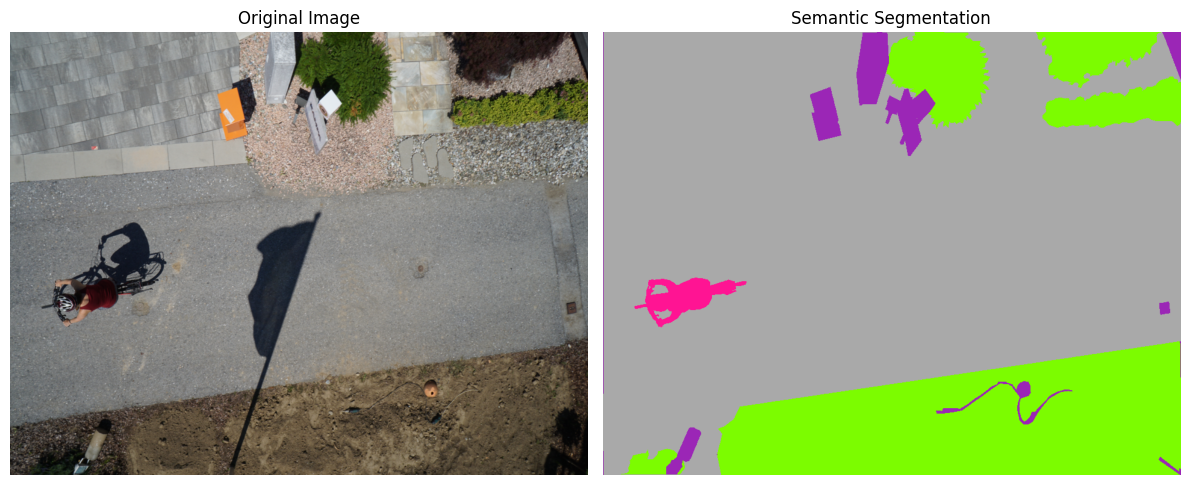

In [ ]:
import cv2
import matplotlib.pyplot as plt


image = cv2.imread(image_paths[68])
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

semantic = cv2.imread(semantic_paths[68])


semantic = cv2.cvtColor(semantic, cv2.COLOR_BGR2RGB)


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(image)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(semantic)
axes[1].set_title("Semantic Segmentation")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
semantic_rgb = cv2.cvtColor(
    cv2.imread(semantic_paths[0]),
    cv2.COLOR_BGR2RGB
)

print("Shape:", semantic_rgb.shape)
print("Unique colors:", np.unique(semantic_rgb.reshape(-1, 3), axis=0))

Shape: (736, 960, 3)
Unique colors: [[ 14 135 204]
 [124 252   0]
 [155  38 182]
 [169 169 169]
 [255  20 147]]


In [ ]:
class Semantic_dataset(Dataset):
    def __init__(self,image_paths,semantic_paths,transform=None):
        self.image_paths = image_paths
        self.semantic_paths = semantic_paths
        self.transform = transform
        self.color_to_class = {
             (155, 38, 182): 0,   # obstacles
            (14, 135, 204): 1,   # water
            (124, 252, 0): 2,    # nature
            (255, 20, 147): 3,   # moving
            (169, 169, 169): 4   # landable
        }
    def __len__(self):
        return len(self.image_paths)
    def __getitem__(self,index):
        image = self.image_paths[index]
        image = cv2.imread(image)
        image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        image = cv2.resize(image,(224,224),interpolation=cv2.INTER_LINEAR)

        image = torch.tensor(image,dtype=torch.float32)

        image = image.permute(2,0,1)
        image = image / 255.0

        if self.transform is not None:
            image = self.transform(image)


        semantic = self.semantic_paths[index]
        semantic = cv2.imread(semantic)
        semantic = cv2.cvtColor(semantic,cv2.COLOR_BGR2RGB)
        semantic = cv2.resize(semantic,(224,224),interpolation=cv2.INTER_NEAREST)

        mask = np.zeros(semantic.shape[:2],dtype=np.int64)
        for clr,cls_id in self.color_to_class.items():
            mask[np.all(semantic==clr,axis=-1)] = cls_id
        mask = torch.tensor(mask,dtype=torch.long)
        return image,mask


In [ ]:
transform = transforms.Compose([
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
ds = Semantic_dataset(image_paths,semantic_paths,transform)

In [ ]:
print(len(ds))

400


In [ ]:
def index_splitter(number,amount):
    indices = np.arange(number)
    amount = torch.tensor(amount)
    amount = amount * number
    amount = amount / 100
    amount = amount.int()
    amount[0] += (number-amount.sum())
    split1, split2,split3 = random_split(indices,amount)
    return split1.indices,split2.indices,split3.indices

In [ ]:
train_indices,test_indices,val_indices = index_splitter(len(ds),[88,7,5])

In [ ]:
train_set = Subset(ds,train_indices)
test_set = Subset(ds,test_indices)
val_set = Subset(ds,val_indices)

In [ ]:
print(len(train_set))
print(len(test_set))
print(len(val_set))

352
28
20


In [ ]:
train_loader = DataLoader(train_set,batch_size=32,shuffle=True)
val_loader = DataLoader(val_set,batch_size=32)
test_loader = DataLoader(test_set,batch_size=32)

In [ ]:
for img,msk in train_loader:
    print(img.shape)
    print(msk.shape)
    break

torch.Size([32, 3, 224, 224])
torch.Size([32, 224, 224])


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self,in_channels,out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels,out_channels,kernel_size=3,padding=1),
            nn.ReLU(inplace=True)
        )
    def forward(self,x):
        return self.block(x)
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(3,64)
        self.enc2 = DoubleConv(64,128)
        self.enc3 = DoubleConv(128,256)
        self.enc4 = DoubleConv(256,512)

        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

        self.bottleneck = DoubleConv(512,1024)


        self.up4 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.dec4 = DoubleConv(1024,512)

        self.up3 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.dec3 = DoubleConv(512,256)

        self.up2= nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.dec2 = DoubleConv(256,128)

        self.up1 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.dec1 = DoubleConv(128,64)

        self.final = nn.Conv2d(64,5,kernel_size=1)

    def forward(self,x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b)
        d4 = torch.cat([d4,e4],dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3,e3],dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2,e2],dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1,e1],dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [ ]:
class DeepLearner:
    def __init__(self,model,loss_fn,optimizer):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = model.to(self.device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.best_model_weights = None
        self.best_val_loss = float("inf")
        self.last_optimizer_state = None
        self.last_model_weights = None
        self.train_losses = []
        self.val_losses = []
        self.epoch = 0
        self.test_loader = None
        self.train_loader = None
        self.val_loader = None
    def set_loaders(self,train_loader=None,val_loader=None,test_loader=None):
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.test_loader
    def train_each_batch(self):
        self.model.train()
        total_loss = 0.0
        for images,masks in self.train_loader:
            images = images.to(self.device)
            masks = masks.to(self.device)
            self.optimizer.zero_grad()
            pred_masks = self.model(images)
            train_loss = self.loss_fn(pred_masks,masks)
            total_loss += train_loss.item()
            train_loss.backward()
            self.optimizer.step()
        total_loss = total_loss/len(self.train_loader)
        return total_loss
    def validate_each_batch(self):
        self.model.eval()
        total_loss = 0.0
        for images,masks in self.val_loader:
            images = images.to(self.device)
            masks = masks.to(self.device)
            pred_masks = self.model(images)
            val_loss = self.loss_fn(pred_masks,masks)
            total_loss += val_loss.item()
        total_loss = total_loss/len(self.val_loader)
        return total_loss
    def pick_the_best_model(self):
        self.model.load_state_dict(self.best_model_weights)
    def plot(self,starting_index):
        epochs = range(starting_index+1, len(self.train_losses) + 1)

        plt.figure(figsize=(8, 5))
        plt.plot(epochs, self.train_losses[starting_index:], marker="o", label="Training Loss")
        plt.plot(epochs, self.val_losses[starting_index:], marker="o", label="Validation Loss")


        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss")
        plt.xticks(epochs)
        plt.legend()
        plt.grid(True)

        plt.show()
    def train(self,n_epochs):
        if self.epoch!=0:
            self.model.load_state_dict(self.last_model_weights)
            self.optimizer.load_state_dict(self.last_optimizer_state)
        initial_epoch = self.epoch
        print("Device:",self.device)
        while self.epoch + 1 <= initial_epoch + n_epochs:
            starting_time = time.time()
            self.epoch  += 1
            train_loss = self.train_each_batch()
            self.train_losses.append(train_loss)
            val_loss = self.validate_each_batch()
            self.val_losses.append(val_loss)
            print("Epoch:",self.epoch)
            gap = time.time()-starting_time
            mins = int(gap//60)
            seconds = int(gap-mins*60)
            second_string = "seconds"
            if seconds == 1:
                second_string = "second"
            print("Duration:",mins,"minutes and",seconds,second_string)
            print("Training Loss:",train_loss)
            print("Validation Loss:",val_loss)
            if val_loss<self.best_val_loss:
                self.best_val_loss = val_loss
                self.best_model_weights = copy.deepcopy(self.model.state_dict())
                self.best_opt_state = copy.deepcopy(self.optimizer.state_dict())
                print("✅Best Model saved from epoch",self.epoch,"with validation loss",val_loss)
        self.last_model_weights = copy.deepcopy(self.model.state_dict())
        self.last_optimizer_state = copy.deepcopy(self.optimizer.state_dict())
        self.plot(initial_epoch)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
def get_colored_predicted_mask(pred_mask,predicted_mask=True):
    if predicted_mask:
        class_id_indices = torch.argmax(pred_mask,dim=1)
    else:
        class_id_indices = pred_mask
    color_to_class = {
    (155, 38, 182): 0,   # obstacles
    (14, 135, 204): 1,   # water
    (124, 252, 0): 2,    # nature
    (255, 20, 147): 3,   # moving
    (169, 169, 169): 4   # landable
    }

    colored_mask = torch.zeros(class_id_indices.shape[0],class_id_indices.shape[1],class_id_indices.shape[2],3,dtype=torch.uint8)
    for color,class_id in color_to_class.items():
        colored_mask[class_id_indices == class_id] = torch.tensor(color,dtype=torch.uint8)
    return colored_mask

def plot_test_image_pred_mask(test_image,pred_mask):
    test_image = test_image.cpu()
    pred_mask = pred_mask[0].cpu()

    test_image = test_image.permute(1,2,0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,1,3)
    std = torch.tensor([0.229,0.224,0.225]).view(1,1,3)

    test_image = test_image * std + mean
    test_image = test_image.clamp(0,1)

    fig, axes = plt.subplots(1,2,figsize=(12,5))

    axes[0].imshow(test_image.numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask.numpy())
    axes[1].set_title("Predicted Semantic Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
device

device(type='cuda')

In [ ]:
_,mask = train_set[9]
unique,counts = torch.unique(mask,return_counts=True)
print(mask)
print("#########")
print(unique)
print("#########")
print(counts)
print(counts.tolist())

tensor([[4, 4, 4,  ..., 2, 2, 2],
        [4, 4, 4,  ..., 2, 2, 2],
        [4, 4, 4,  ..., 2, 2, 2],
        ...,
        [4, 4, 4,  ..., 3, 3, 3],
        [4, 4, 4,  ..., 3, 3, 3],
        [4, 4, 4,  ..., 3, 3, 3]])
#########
tensor([0, 2, 3, 4])
#########
tensor([ 2089,  4283,  5948, 37856])
[2089, 4283, 5948, 37856]


In [ ]:
class_counts = [0]*5
total_pixels = 0
for i in range(0,len(train_set)):
    _,mask= train_set[i]
    unique, counts = torch.unique(mask,return_counts=True)
    unique =  unique.tolist()
    counts = counts.tolist()
    for i in range(0,len(unique)):
        class_counts[unique[i]] += counts[i]
        total_pixels = total_pixels + counts[i]
for i in range(len(class_counts)):
    class_counts[i] = class_counts[i]/total_pixels
    class_counts[i] *= 100
print(class_counts)



[9.085677506087663, 2.8658836803542442, 33.27144700653699, 2.0900068123840447, 52.68698499463705]


In [ ]:
class_counts = torch.tensor(class_counts,dtype=torch.float32).to(device)
print(class_counts)
class_counts /=100.0
print(class_counts)

tensor([ 9.0857,  2.8659, 33.2714,  2.0900, 52.6870], device='cuda:0')
tensor([0.0909, 0.0287, 0.3327, 0.0209, 0.5269], device='cuda:0')


In [ ]:
class_weights = 1.0 / torch.sqrt(class_counts)
class_weights = class_weights / class_weights.mean()

print(class_weights)

tensor([0.8616, 1.5341, 0.4502, 1.7964, 0.3578], device='cuda:0')


In [ ]:
model = UNet()
loss_fn = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(),lr=1e-3)

In [ ]:
dl = DeepLearner(model,loss_fn,optimizer)
dl.set_loaders(train_loader,val_loader,test_loader)

Device: cuda
Epoch: 1
Duration: 0 minutes and 22 seconds
Training Loss: 1.5763303149830212
Validation Loss: 1.4710261821746826
✅Best Model saved from epoch 1 with validation loss 1.4710261821746826
Epoch: 2
Duration: 0 minutes and 21 seconds
Training Loss: 1.451242208480835
Validation Loss: 1.3178576231002808
✅Best Model saved from epoch 2 with validation loss 1.3178576231002808
Epoch: 3
Duration: 0 minutes and 21 seconds
Training Loss: 1.372572053562511
Validation Loss: 1.1584020853042603
✅Best Model saved from epoch 3 with validation loss 1.1584020853042603
Epoch: 4
Duration: 0 minutes and 22 seconds
Training Loss: 1.7839442166415127
Validation Loss: 1.0989691019058228
✅Best Model saved from epoch 4 with validation loss 1.0989691019058228
Epoch: 5
Duration: 0 minutes and 21 seconds
Training Loss: 1.1395186185836792
Validation Loss: 1.1065860986709595
Epoch: 6
Duration: 0 minutes and 21 seconds
Training Loss: 1.1096768270839343
Validation Loss: 1.032025933265686
✅Best Model saved from

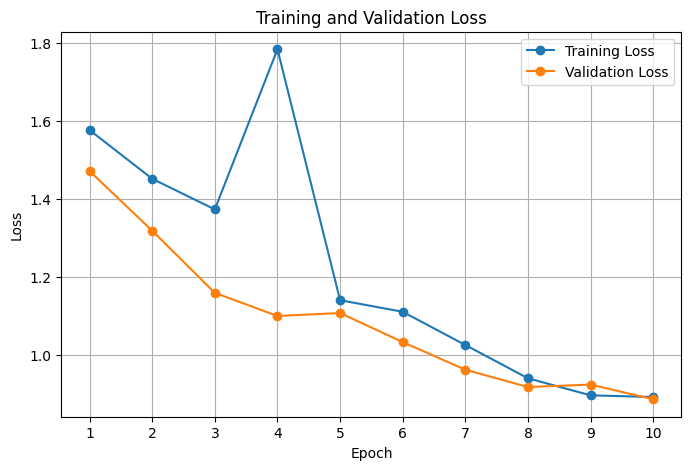

In [ ]:
dl.train(10)

Device: cuda
Epoch: 11
Duration: 0 minutes and 21 seconds
Training Loss: 0.8597041476856578
Validation Loss: 0.8833407163619995
✅Best Model saved from epoch 11 with validation loss 0.8833407163619995
Epoch: 12
Duration: 0 minutes and 21 seconds
Training Loss: 0.8423634334044023
Validation Loss: 0.8628686666488647
✅Best Model saved from epoch 12 with validation loss 0.8628686666488647
Epoch: 13
Duration: 0 minutes and 21 seconds
Training Loss: 0.8470809242942117
Validation Loss: 0.8800497055053711
Epoch: 14
Duration: 0 minutes and 21 seconds
Training Loss: 0.8196716200221669
Validation Loss: 0.8277167081832886
✅Best Model saved from epoch 14 with validation loss 0.8277167081832886
Epoch: 15
Duration: 0 minutes and 21 seconds
Training Loss: 0.8150930296291005
Validation Loss: 0.8203231692314148
✅Best Model saved from epoch 15 with validation loss 0.8203231692314148
Epoch: 16
Duration: 0 minutes and 22 seconds
Training Loss: 0.7963730205189098
Validation Loss: 0.7867884635925293
✅Best Mod

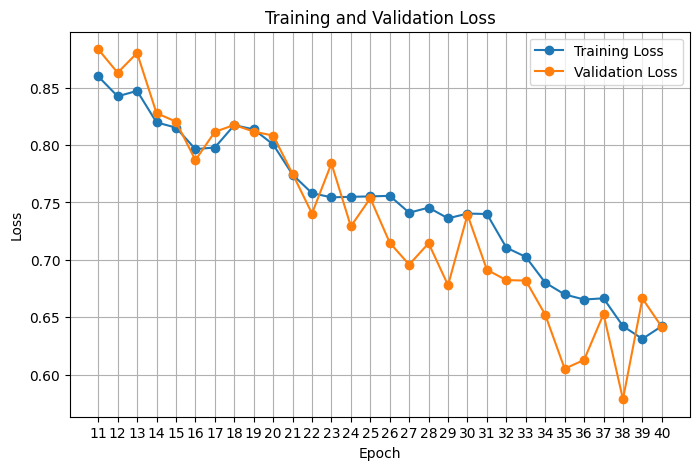

In [ ]:
dl.train(30)

In [ ]:
def plot_test_image_pred_mask_ground_truth_mask(test_image,pred_mask,ground_truth_mask):
    test_image = test_image.cpu()
    pred_mask = pred_mask[0].cpu()
    ground_truth_mask = ground_truth_mask[0].cpu()

    test_image = test_image.permute(1,2,0)
    mean = torch.tensor([0.485,0.456,0.406]).view(1,1,3)
    std = torch.tensor([0.229,0.224,0.225]).view(1,1,3)

    test_image = test_image * std + mean
    test_image = test_image.clamp(0,1)

    fig, axes = plt.subplots(1,3,figsize=(18,5))

    axes[0].imshow(test_image.numpy())
    axes[0].set_title("Original Image")
    axes[0].axis("off")

    axes[1].imshow(pred_mask.numpy())
    axes[1].set_title("Predicted Semantic Mask")
    axes[1].axis("off")

    axes[2].imshow(ground_truth_mask.numpy())
    axes[2].set_title("Ground Truth Semantic Mask")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()



Device: cuda
Epoch: 41
Duration: 0 minutes and 22 seconds
Training Loss: 0.6335371082479303
Validation Loss: 0.5894303321838379
Epoch: 42
Duration: 0 minutes and 21 seconds
Training Loss: 0.6110070998018439
Validation Loss: 0.5748089551925659
✅Best Model saved from epoch 42 with validation loss 0.5748089551925659
Epoch: 43
Duration: 0 minutes and 21 seconds
Training Loss: 0.630012409253554
Validation Loss: 0.698907732963562
Epoch: 44
Duration: 0 minutes and 21 seconds
Training Loss: 0.6336376504464583
Validation Loss: 0.7149519920349121
Epoch: 45
Duration: 0 minutes and 21 seconds
Training Loss: 0.6400352445515719
Validation Loss: 0.5654017329216003
✅Best Model saved from epoch 45 with validation loss 0.5654017329216003
Epoch: 46
Duration: 0 minutes and 21 seconds
Training Loss: 0.594643538648432
Validation Loss: 0.571904718875885
Epoch: 47
Duration: 0 minutes and 21 seconds
Training Loss: 0.5709607167677446
Validation Loss: 0.5576052069664001
✅Best Model saved from epoch 47 with valid

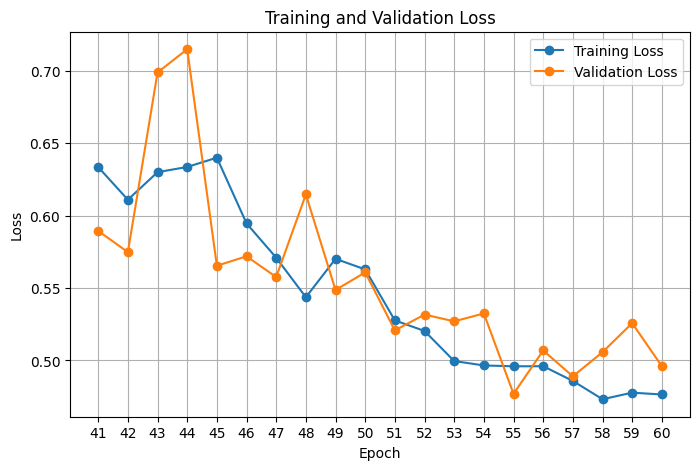

In [ ]:
dl.train(20)

Device: cuda
Epoch: 61
Duration: 0 minutes and 21 seconds
Training Loss: 0.488076315684752
Validation Loss: 0.4699338972568512
✅Best Model saved from epoch 61 with validation loss 0.4699338972568512
Epoch: 62
Duration: 0 minutes and 21 seconds
Training Loss: 0.48599019104784186
Validation Loss: 0.48688289523124695
Epoch: 63
Duration: 0 minutes and 21 seconds
Training Loss: 0.5034196891567924
Validation Loss: 0.49710801243782043
Epoch: 64
Duration: 0 minutes and 21 seconds
Training Loss: 0.47862974351102655
Validation Loss: 0.47894221544265747
Epoch: 65
Duration: 0 minutes and 21 seconds
Training Loss: 0.44363891265609046
Validation Loss: 0.4859214127063751
Epoch: 66
Duration: 0 minutes and 21 seconds
Training Loss: 0.43816921656781976
Validation Loss: 0.48588046431541443
Epoch: 67
Duration: 0 minutes and 21 seconds
Training Loss: 0.42857432094487274
Validation Loss: 0.4587276875972748
✅Best Model saved from epoch 67 with validation loss 0.4587276875972748
Epoch: 68
Duration: 0 minutes 

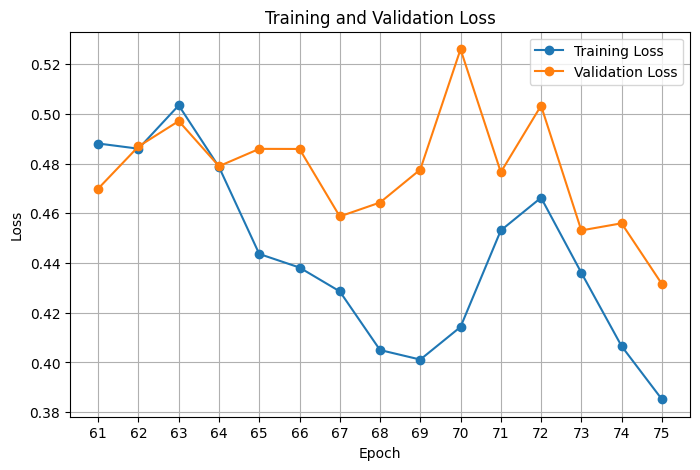

In [ ]:
dl.train(15)

Device: cuda
Epoch: 76
Duration: 0 minutes and 22 seconds
Training Loss: 0.370648362419822
Validation Loss: 0.41895073652267456
✅Best Model saved from epoch 76 with validation loss 0.41895073652267456
Epoch: 77
Duration: 0 minutes and 21 seconds
Training Loss: 0.3683138462630185
Validation Loss: 0.4370545744895935
Epoch: 78
Duration: 0 minutes and 21 seconds
Training Loss: 0.3483706306327473
Validation Loss: 0.4143142104148865
✅Best Model saved from epoch 78 with validation loss 0.4143142104148865
Epoch: 79
Duration: 0 minutes and 21 seconds
Training Loss: 0.3377208113670349
Validation Loss: 0.44469013810157776
Epoch: 80
Duration: 0 minutes and 21 seconds
Training Loss: 0.3373226523399353
Validation Loss: 0.39421457052230835
✅Best Model saved from epoch 80 with validation loss 0.39421457052230835
Epoch: 81
Duration: 0 minutes and 21 seconds
Training Loss: 0.32318406755273993
Validation Loss: 0.40770894289016724
Epoch: 82
Duration: 0 minutes and 21 seconds
Training Loss: 0.3129452494057

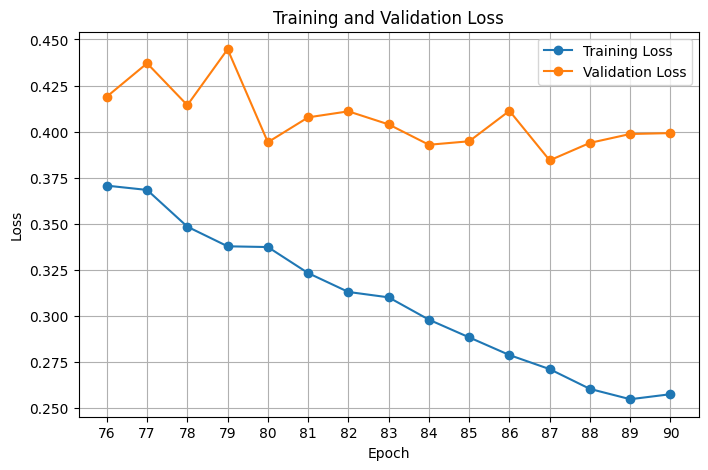

In [ ]:
dl.train(15)

Image: 1


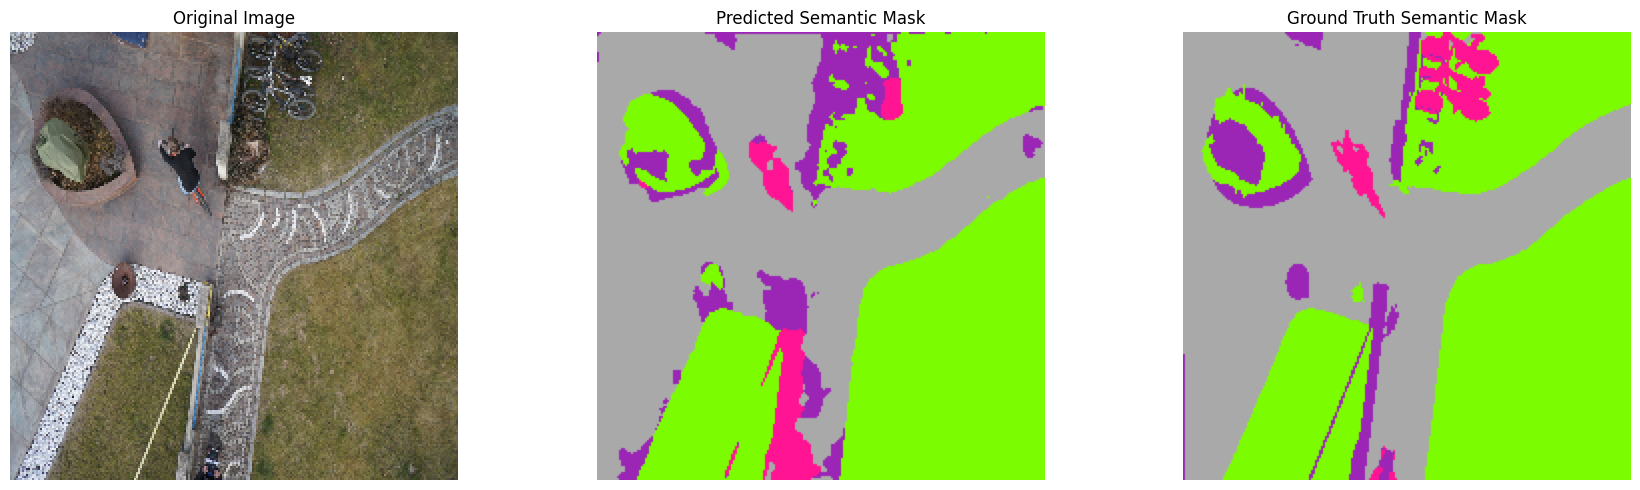

Image: 2


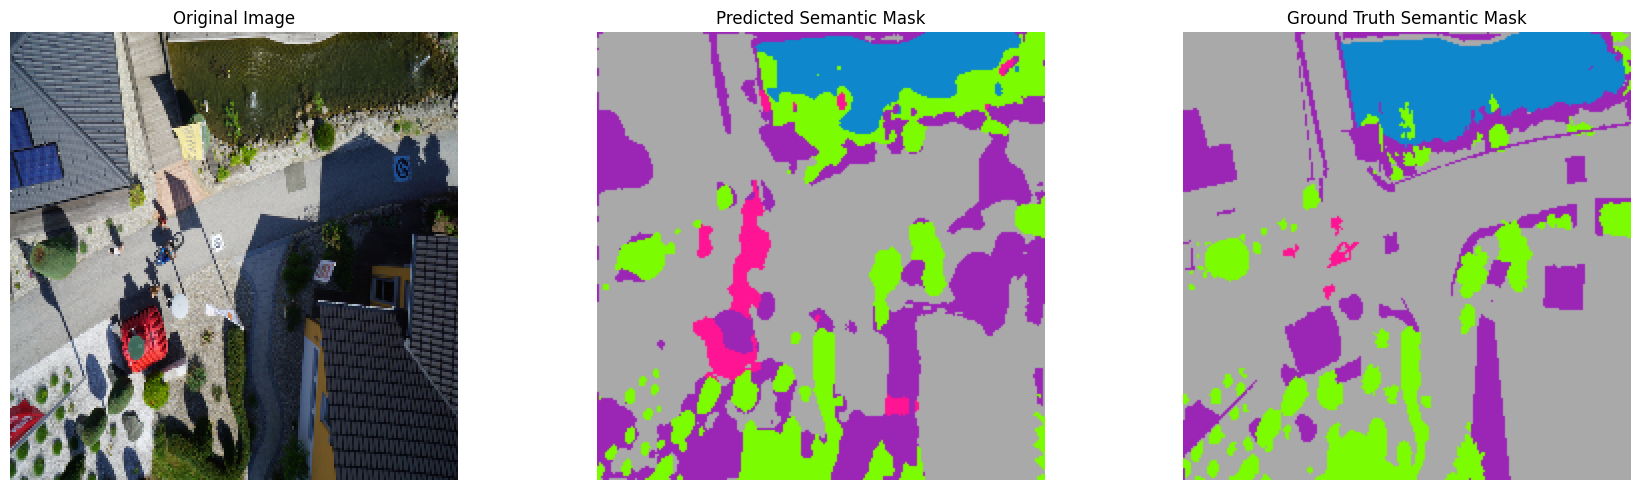

Image: 3


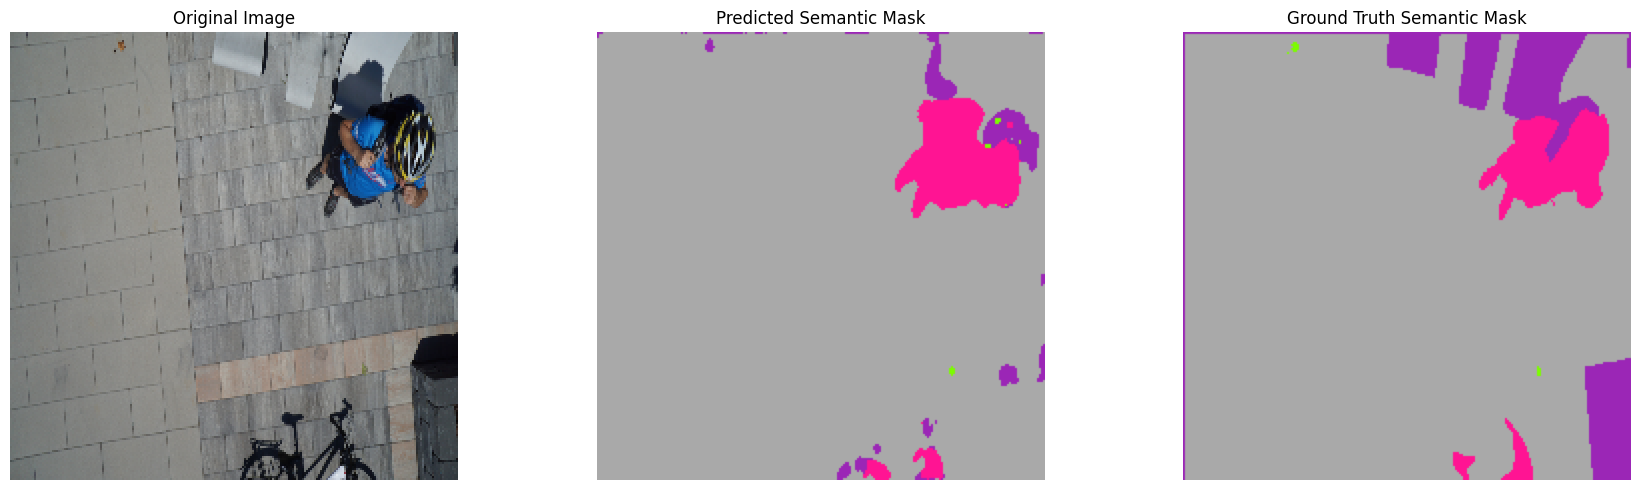

Image: 4


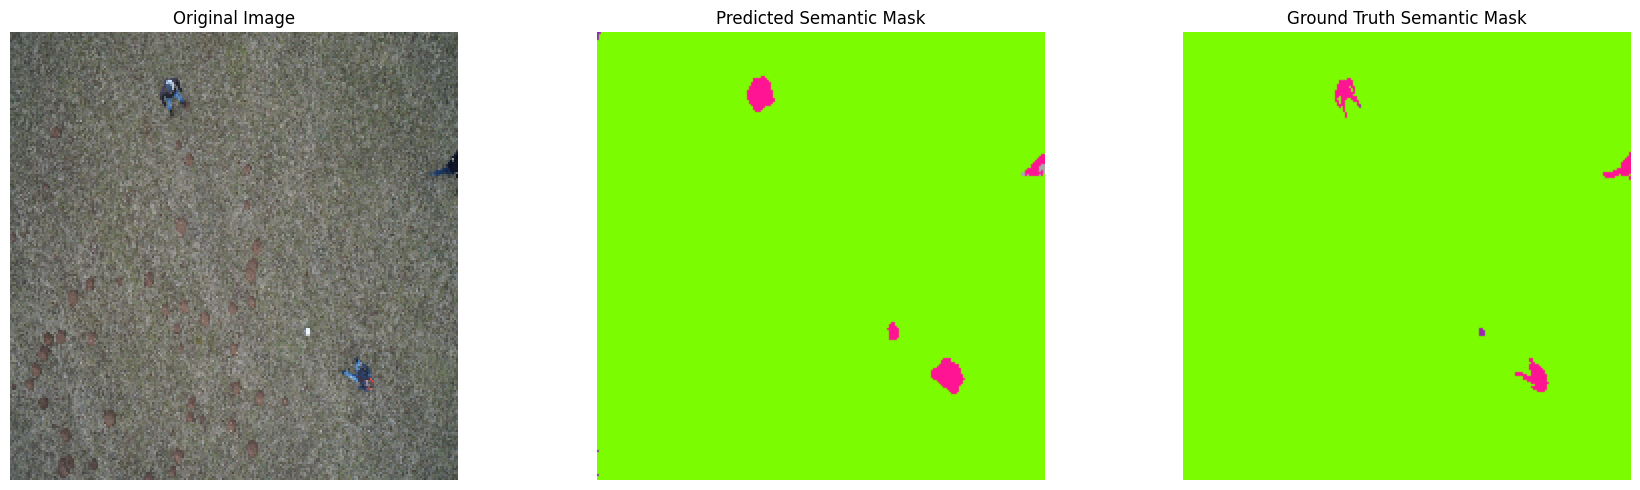

Image: 5


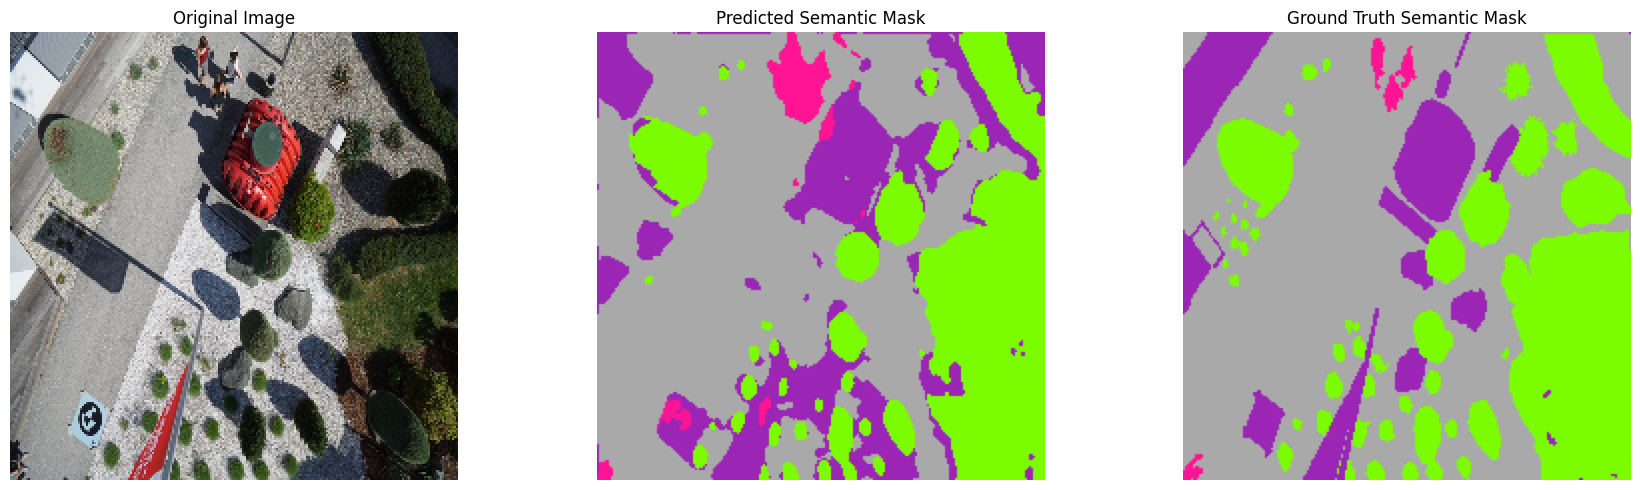

Image: 6


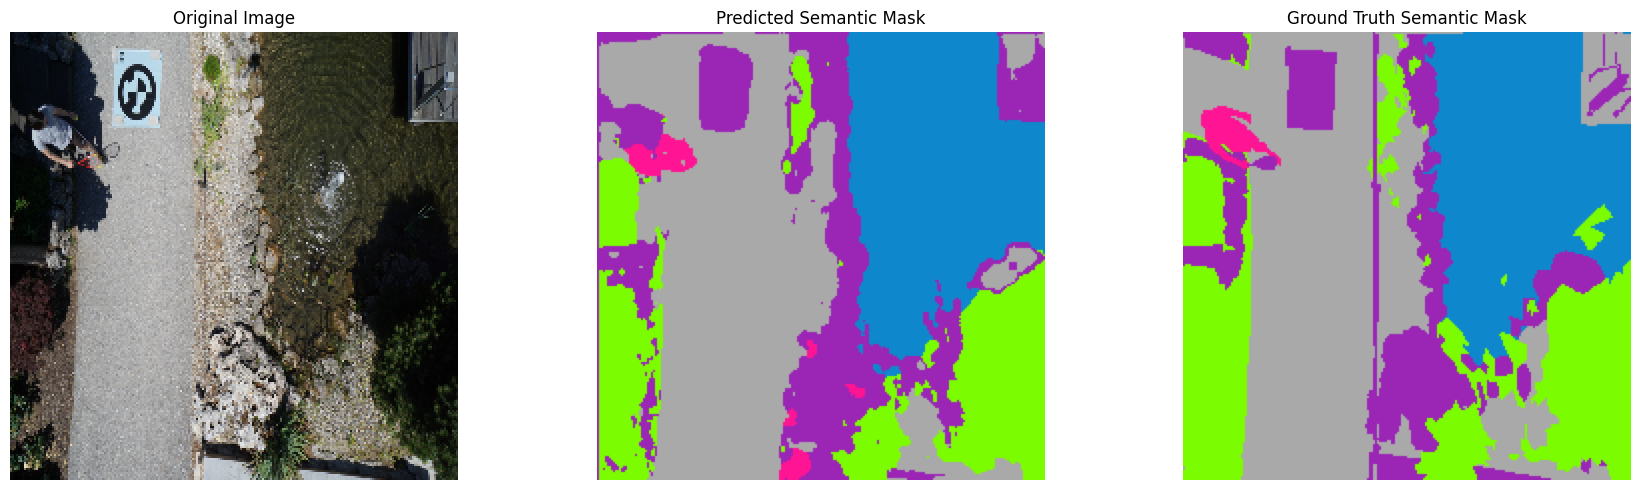

Image: 7


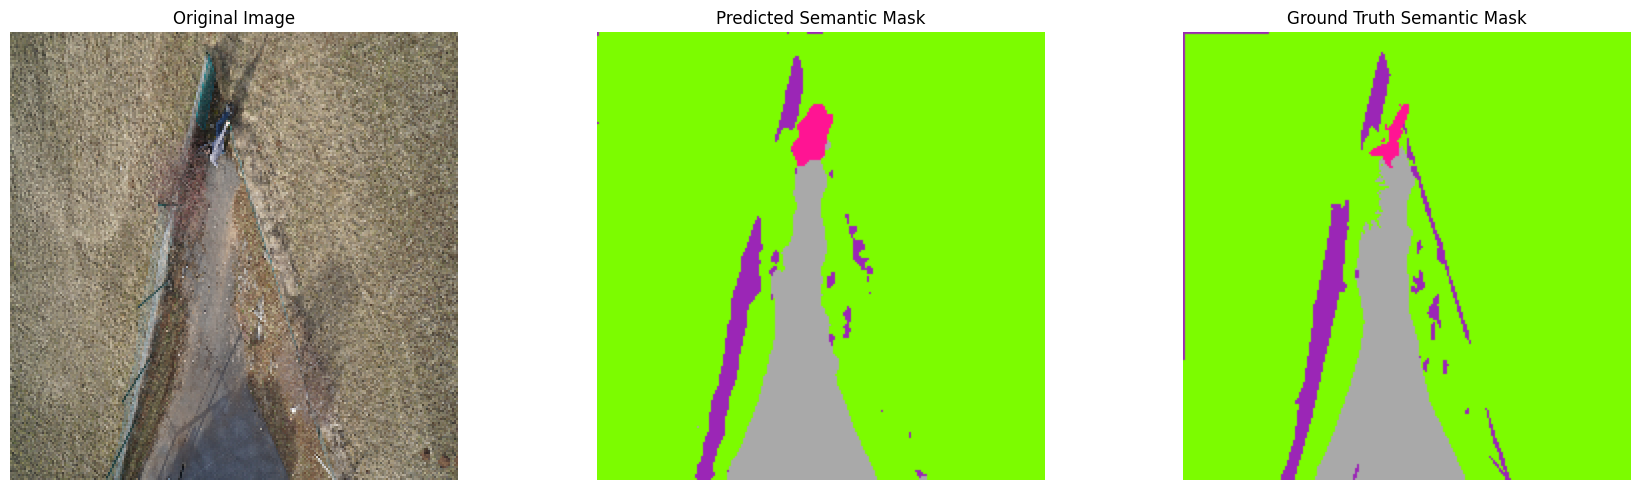

Image: 8


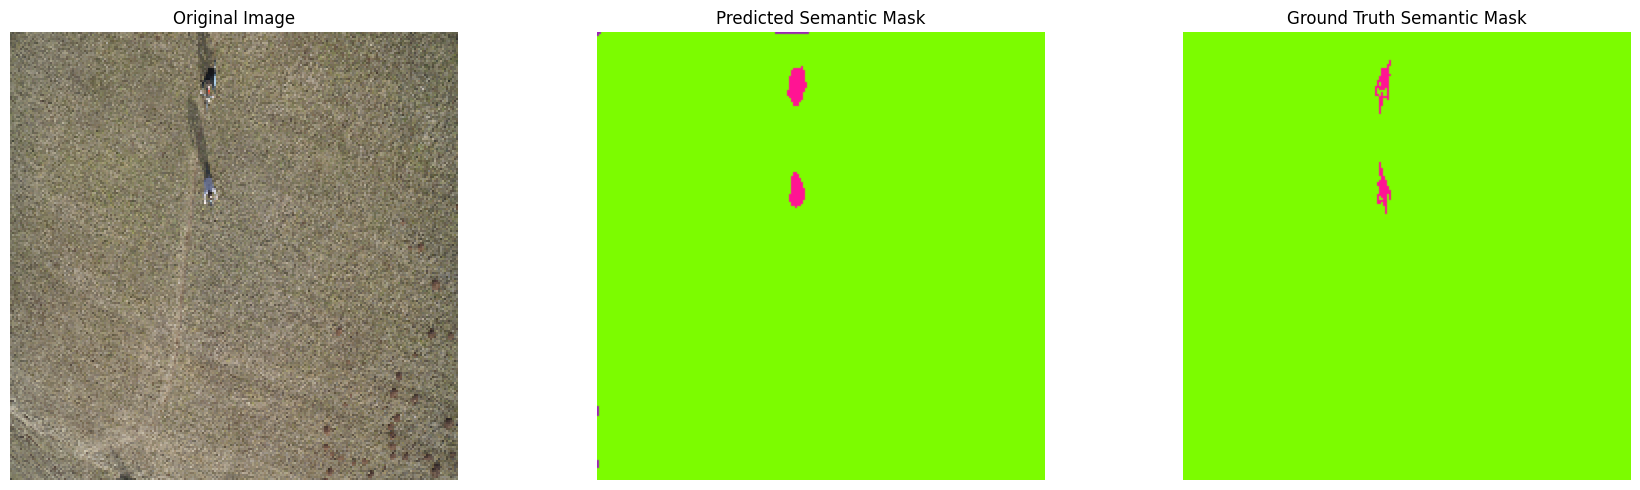

Image: 9


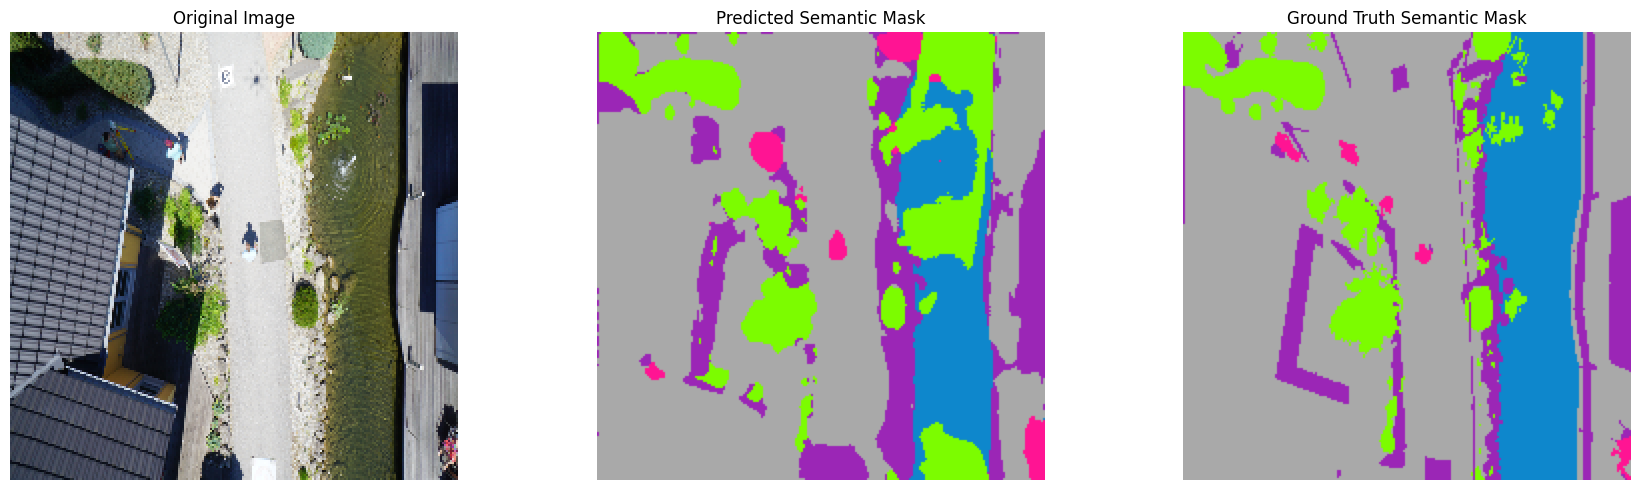

Image: 10


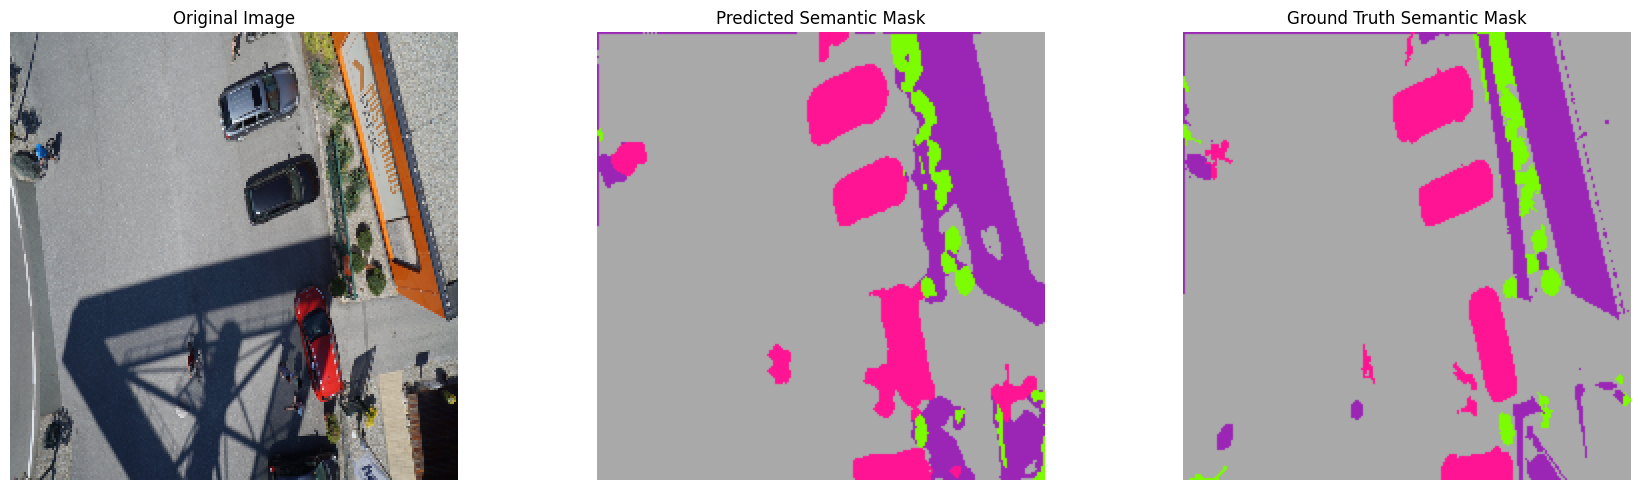

Image: 11


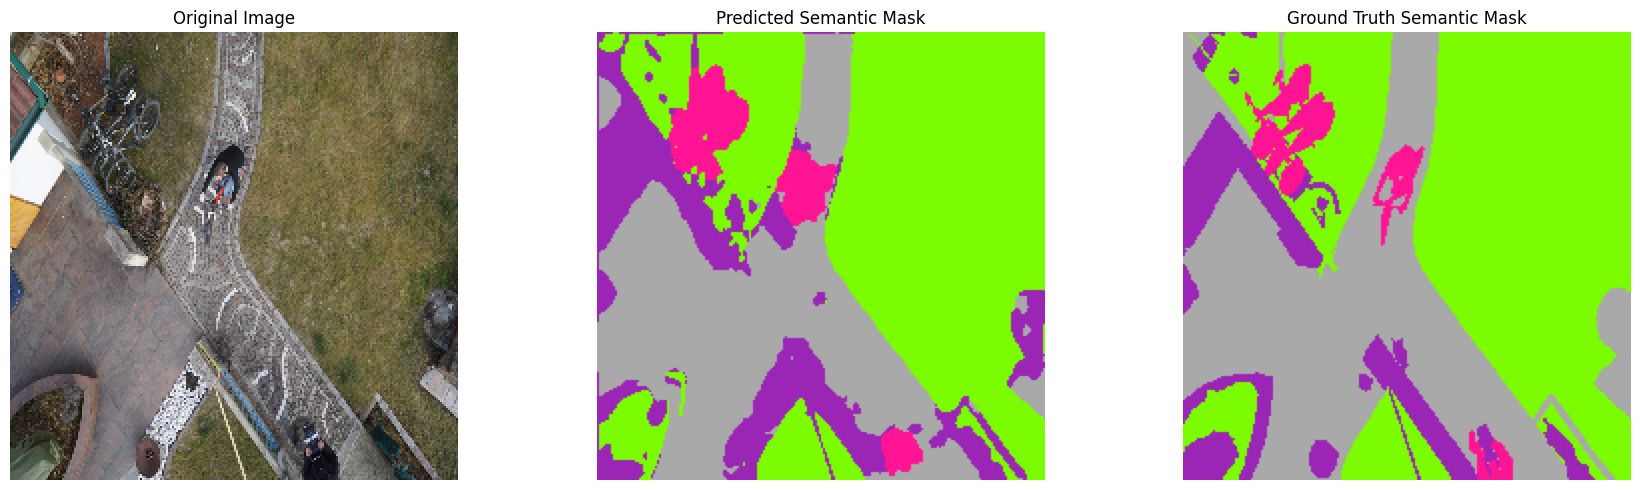

Image: 12


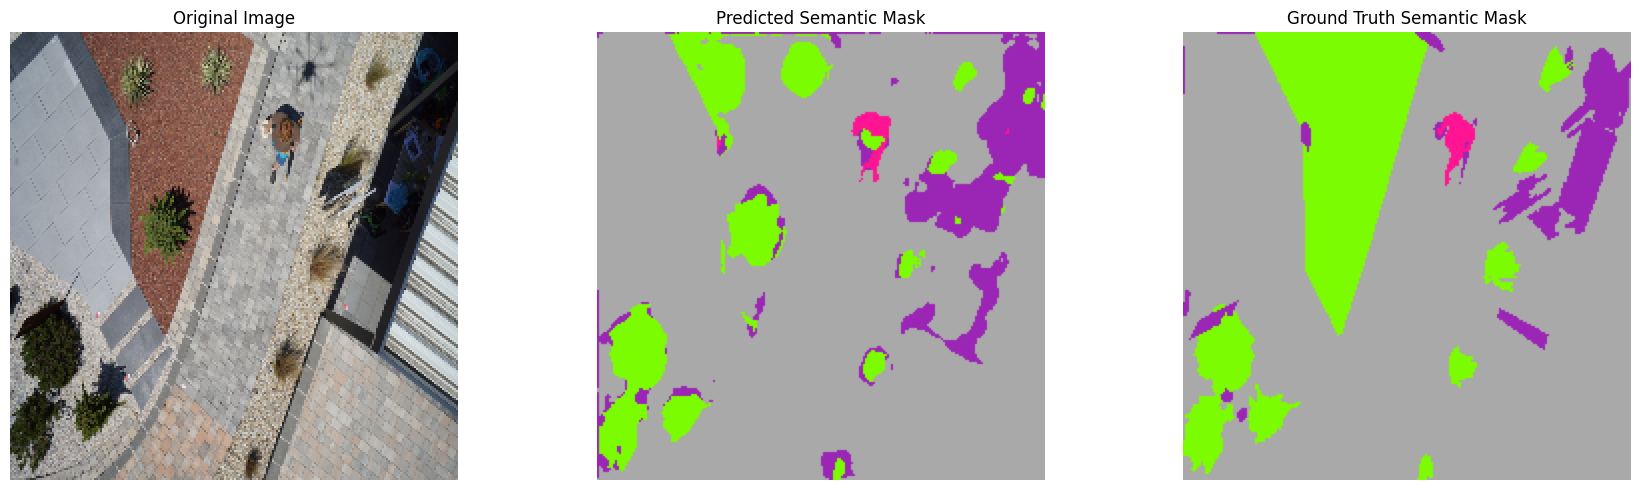

Image: 13


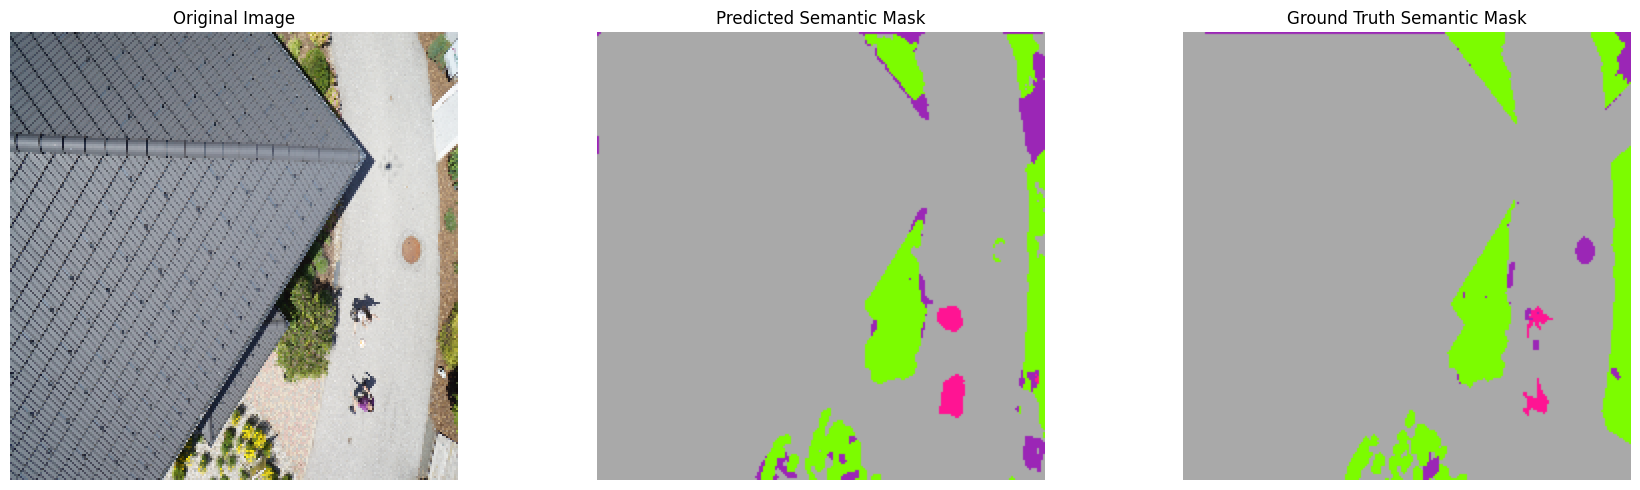

Image: 14


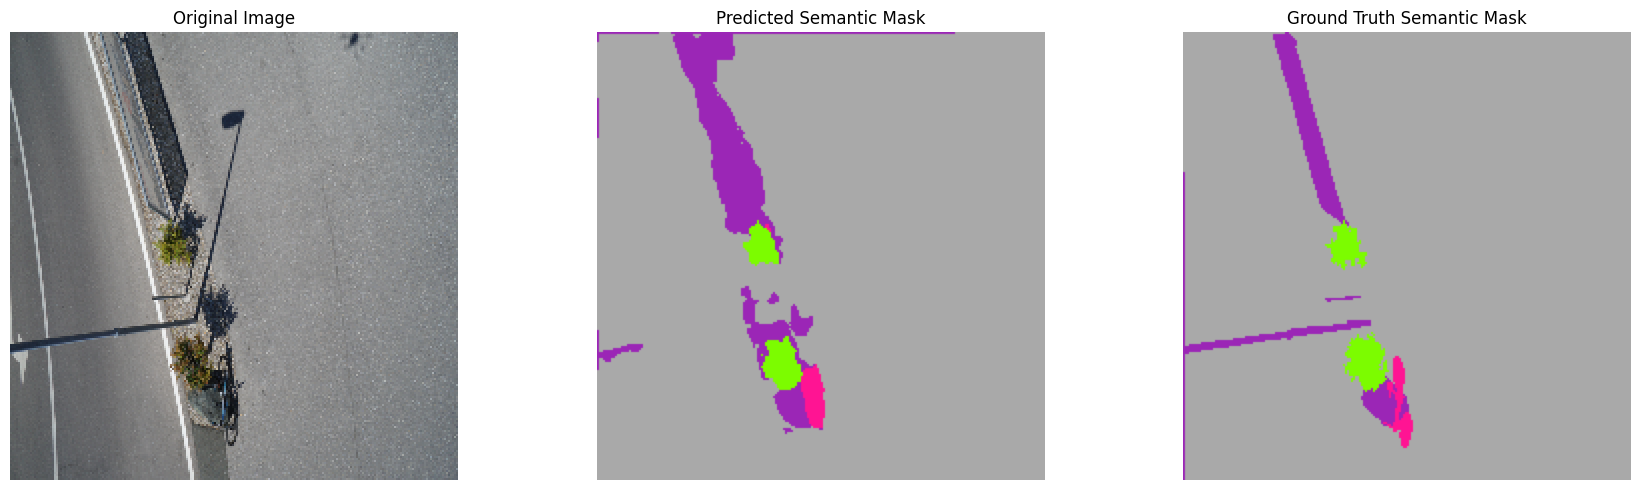

Image: 15


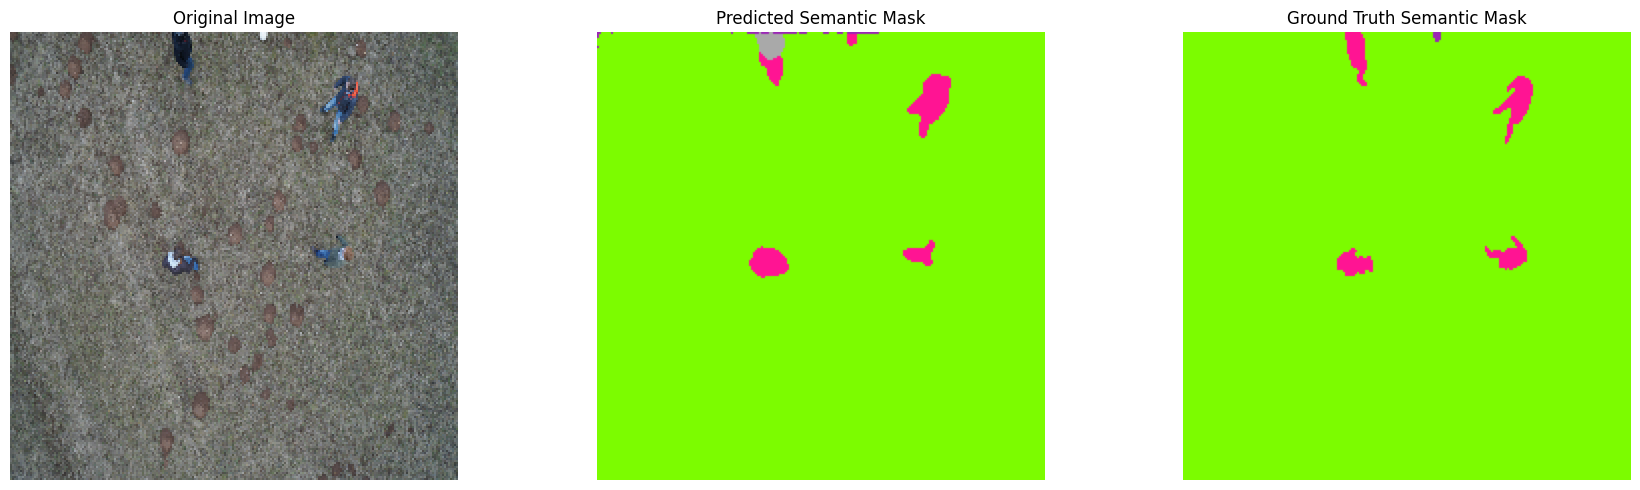

Image: 16


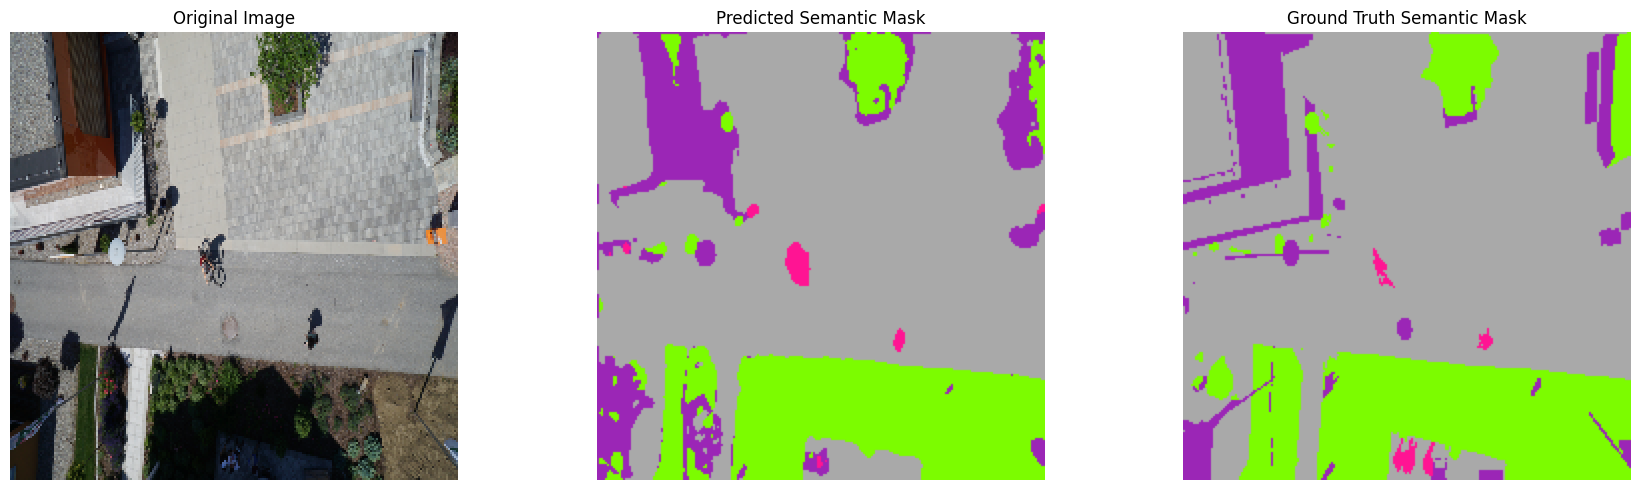

Image: 17


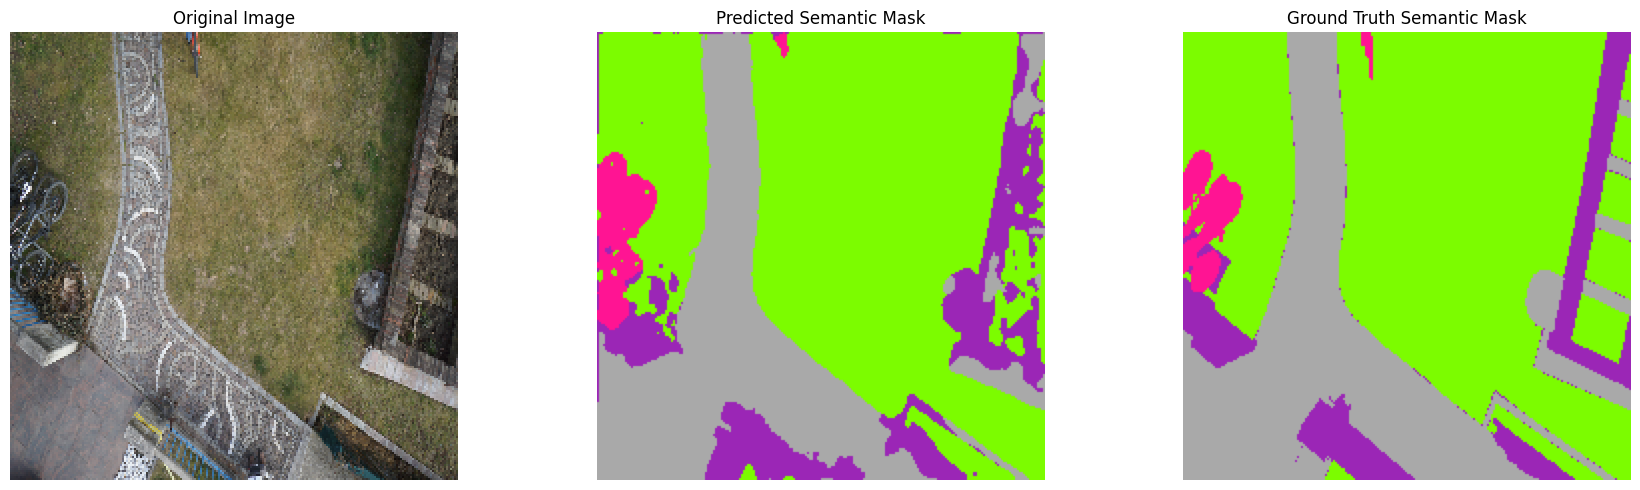

Image: 18


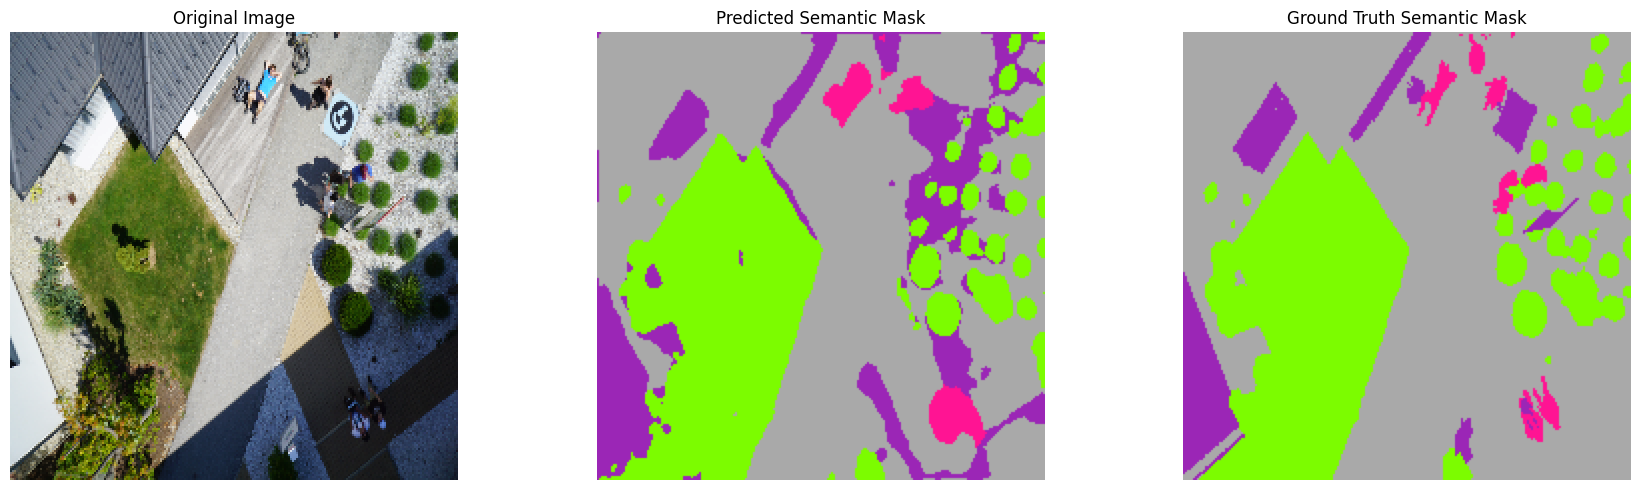

Image: 19


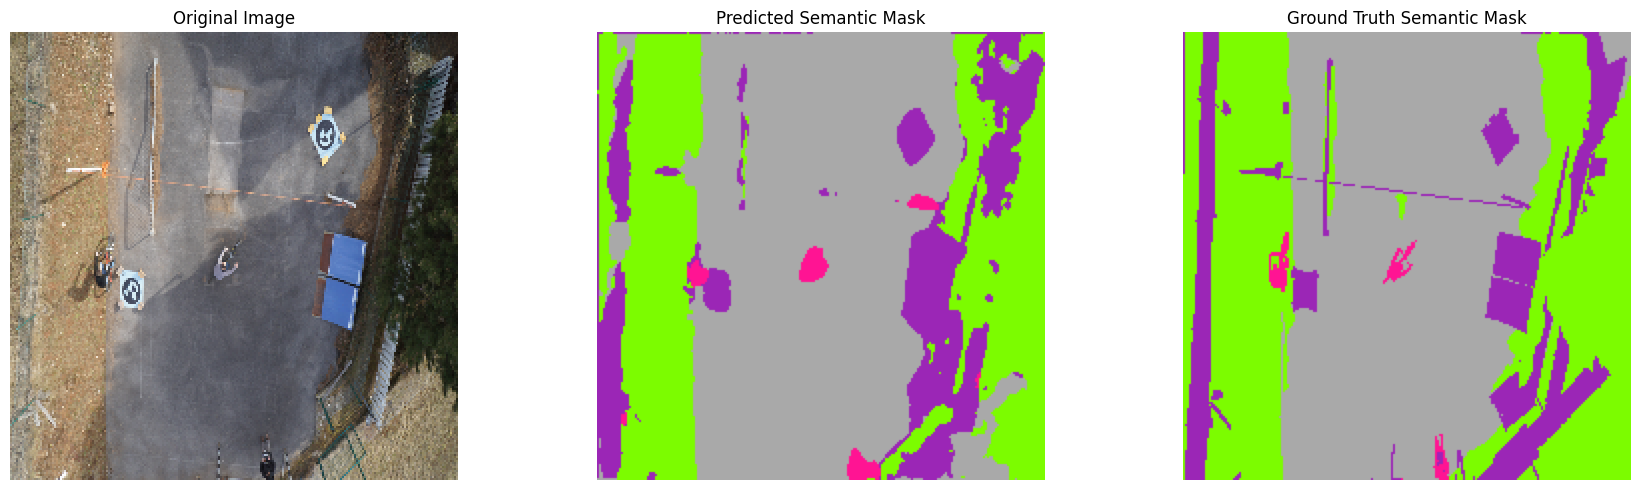

Image: 20


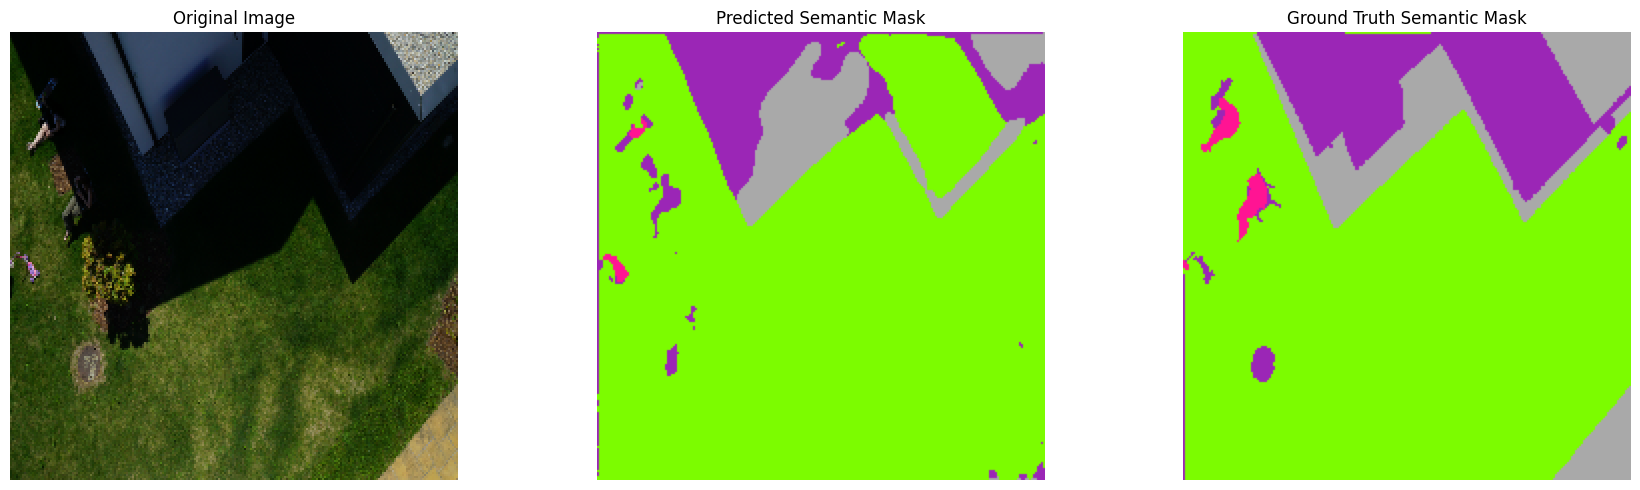

Image: 21


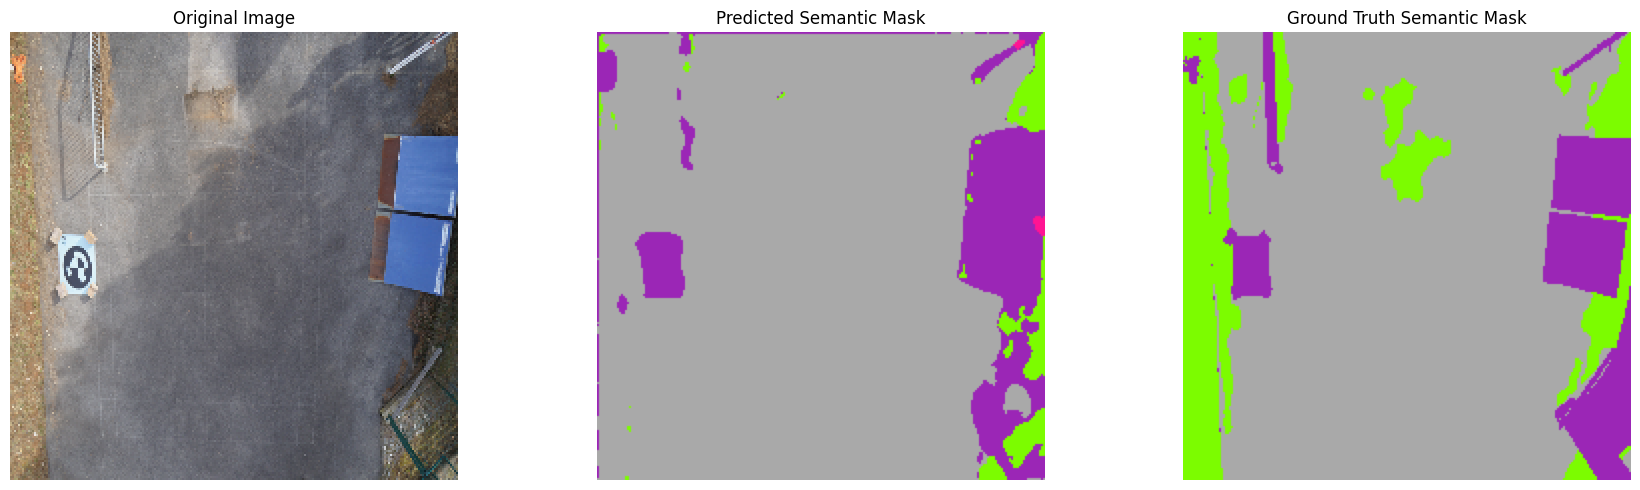

Image: 22


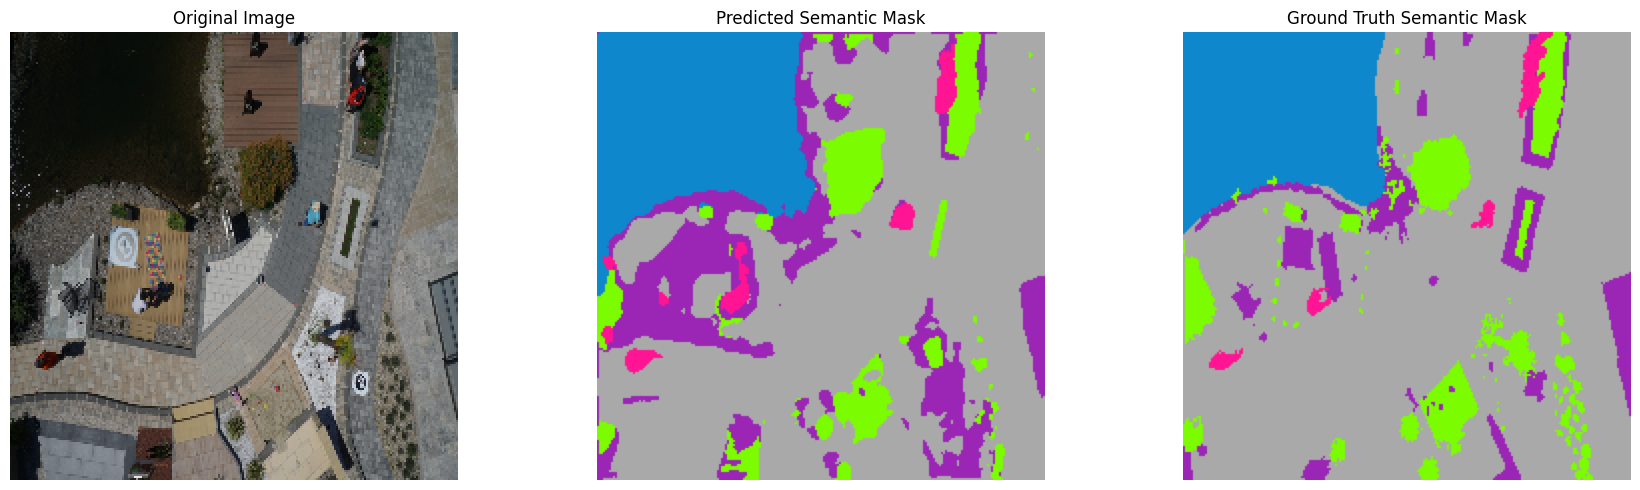

Image: 23


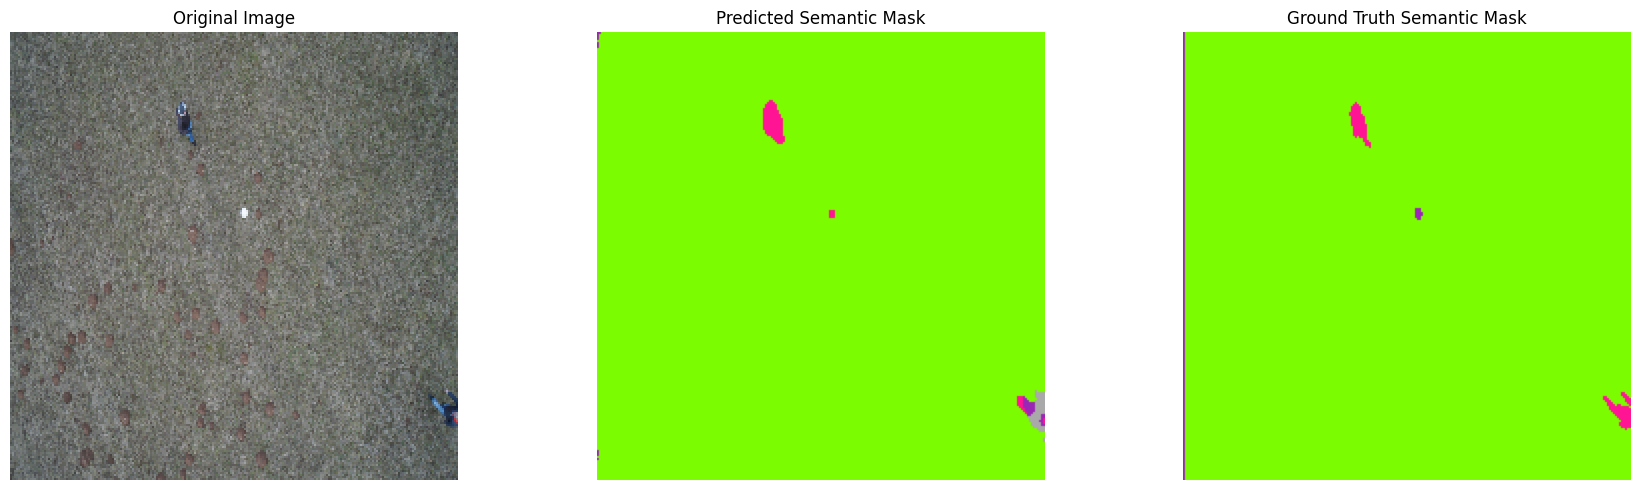

Image: 24


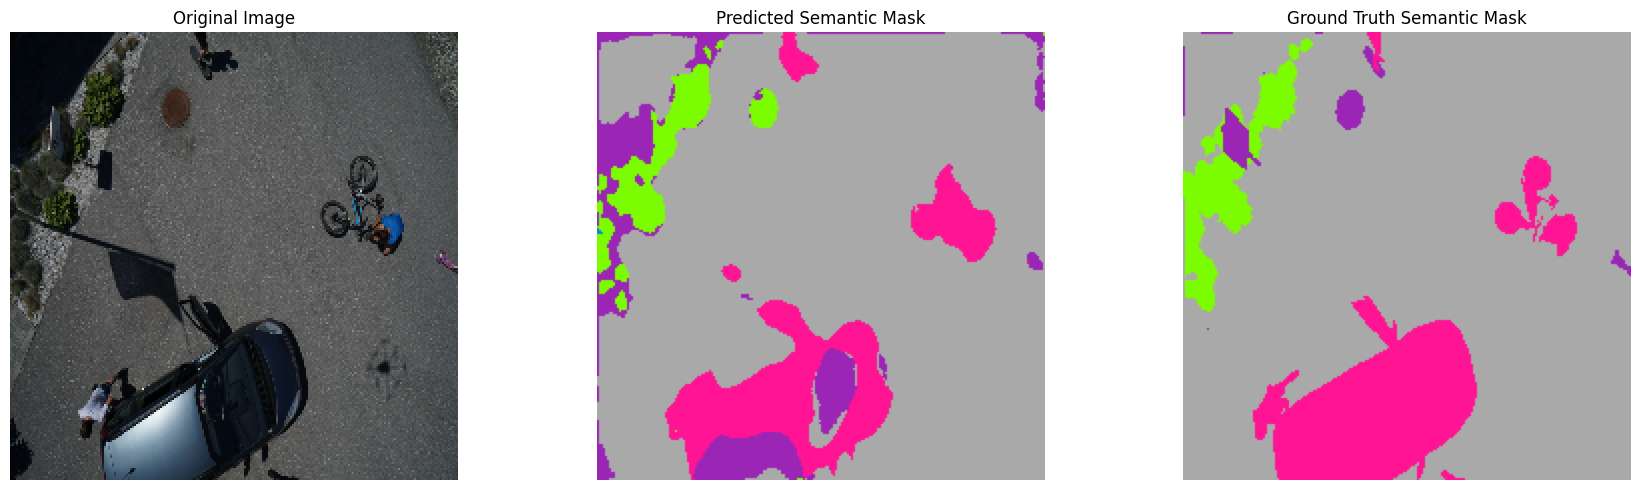

Image: 25


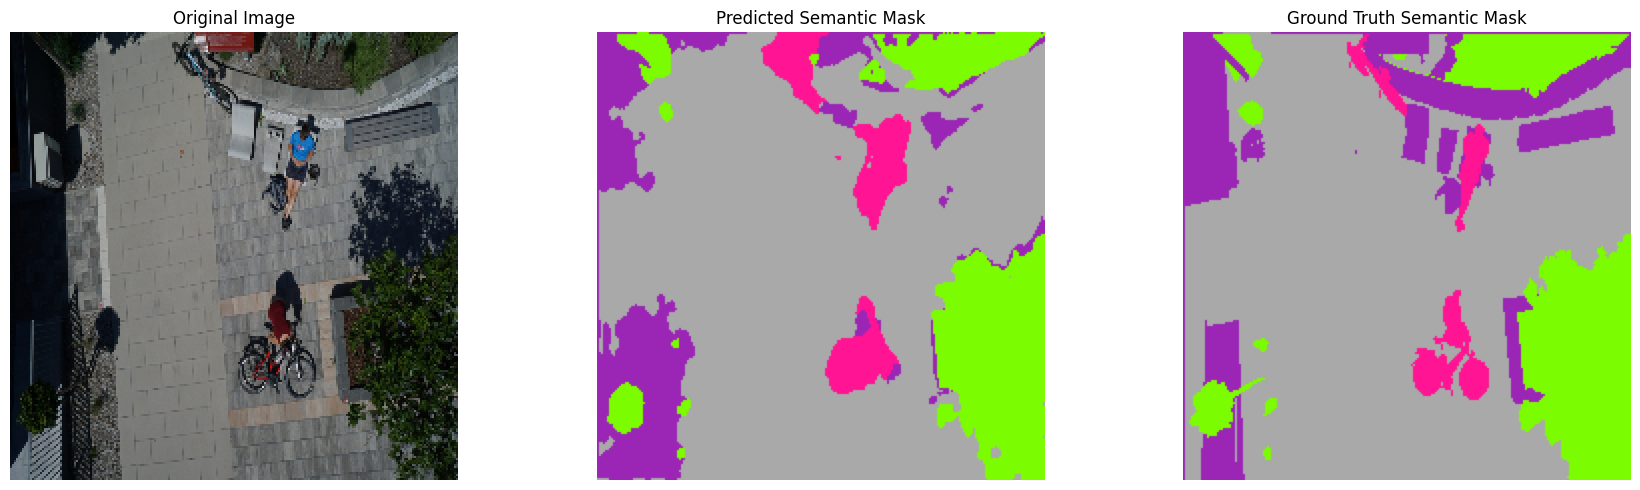

Image: 26


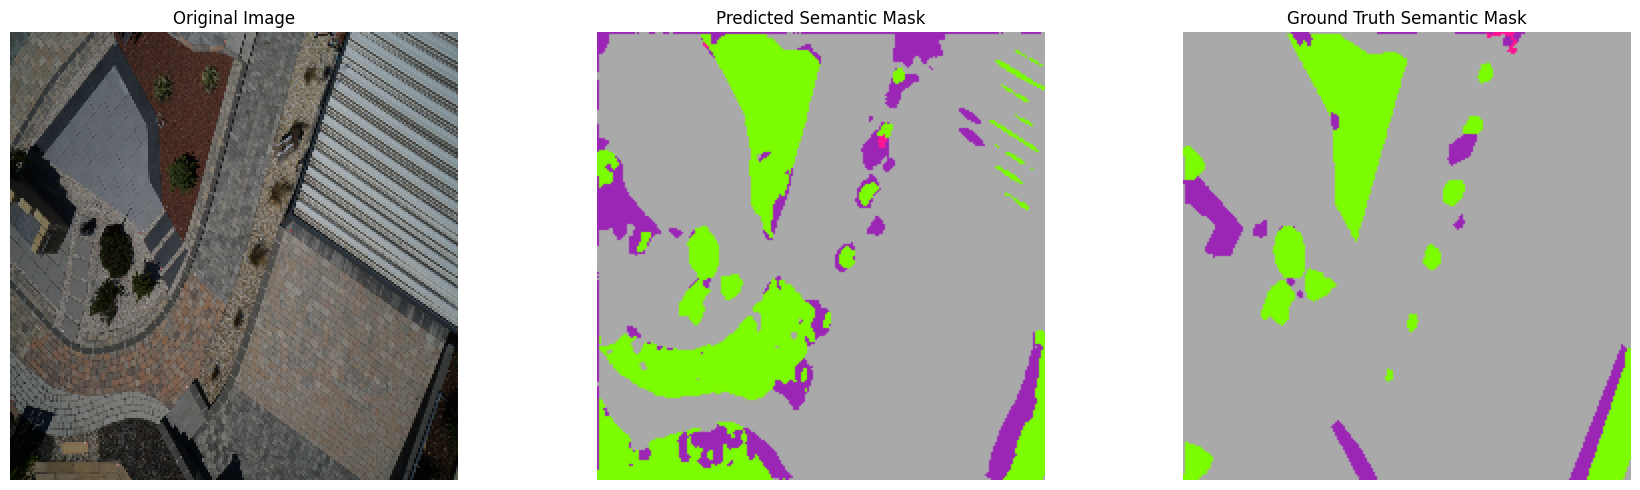

Image: 27


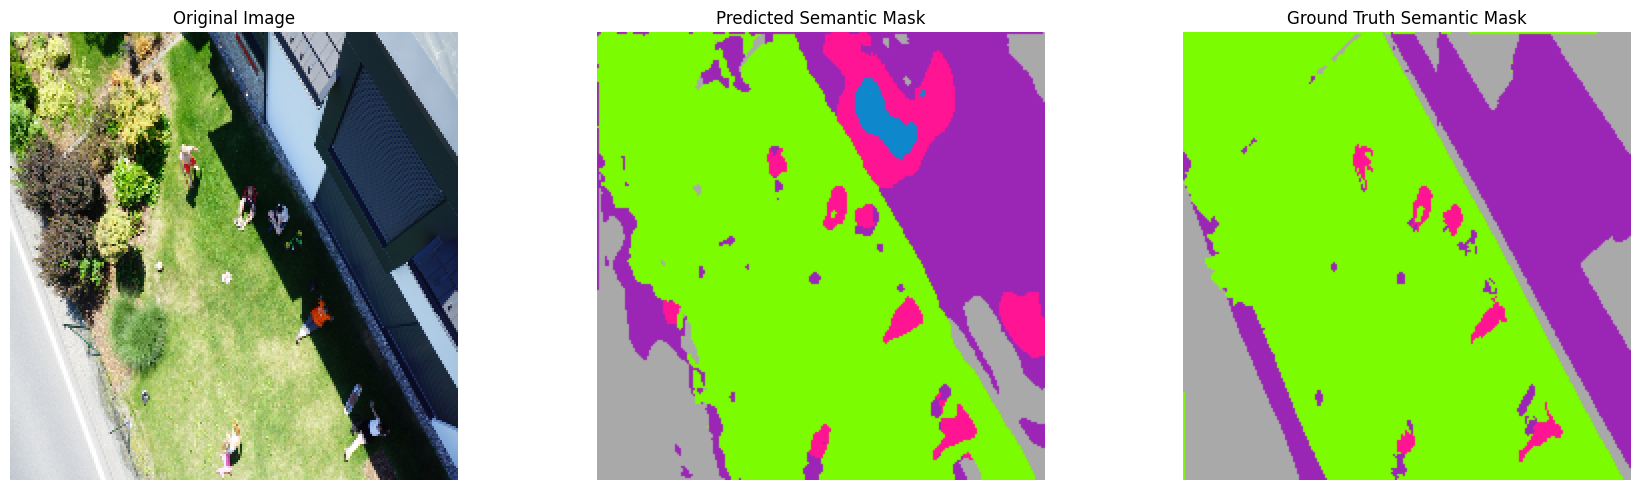

Image: 28


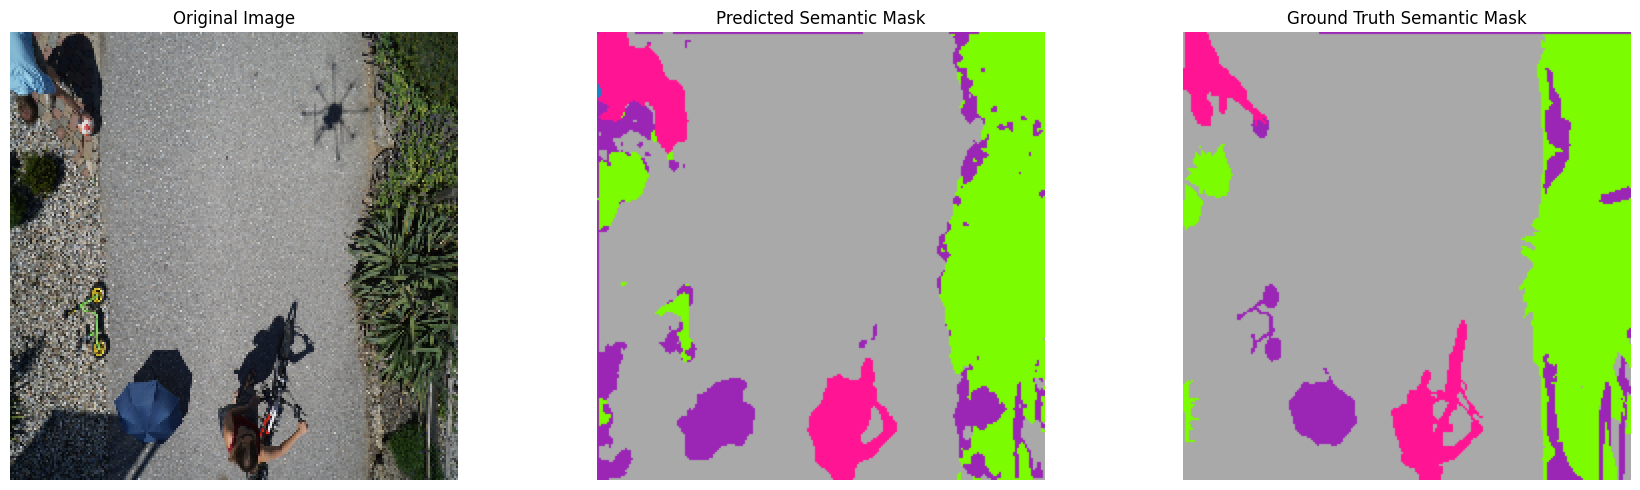

In [ ]:
dl.pick_the_best_model()
dl.model.eval()
for i in range(0,len(test_set)):
    print("Image:",i+1)
    im_test,msk_test = test_set[i]
    im_test = im_test.to(device)
    msk_test = msk_test.to(device)
    pred_mask = dl.model(im_test.unsqueeze(0))
    pred_mask = get_colored_predicted_mask(pred_mask)
    msk_test = get_colored_predicted_mask(msk_test.unsqueeze(0),predicted_mask=False)
    plot_test_image_pred_mask_ground_truth_mask(im_test,pred_mask,msk_test)